<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
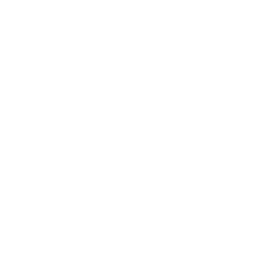
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analýza spolehlivosti zařízení podle generace</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Výroba / Spolehlivostní inženýrství &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Shrnutí

Tato analýza používá **PROC LIFETEST** k porovnání provozní spolehlivosti tří
po sobě jdoucích generací návrhu CNC frézovacích strojů. Na základě snímku
100 strojů z provozu (75 poruch, 25 jednotek stále v provozu a tedy
pravostranně cenzurovaných) odhaduje Kaplan-Meierovu křivku přežití pro
každou generaci a testuje, zda se křivky liší jak pomocí log-rank testu,
tak testu Gehan-Breslow-Wilcoxon.

Data vyprávějí jasný, jednoskokový příběh. Původní stroje **Generace 1**
jsou výrazně méně spolehlivé než obě pozdější generace: jejich medián
provozní životnosti je **5 282 provozních hodin**, zhruba třetina oproti
**Generaci 2** (**16 430 hodin**) a **Generaci 3** (**13 512 hodin**). Oba
testy homogenity zamítají shodu tří křivek přežití -- log-rank chí-kvadrát
**12,92** (2 st. volnosti, *p* = **0,0016**) a Wilcoxon **11,88** (2 st.
volnosti, *p* = **0,0026**). Při 10 000 provozních hodinách se očekává, že
v provozu zůstane pouze **24 %** strojů Generace 1, oproti **64 %** u
Generace 2 a **57 %** u Generace 3.

Zlepšení **není** plynulým nárůstem mezi generacemi: Generace 2 a Generace
3 přežívají velmi podobným tempem a při této velikosti vzorku jsou od sebe
statisticky nerozlišitelné. Skutečným zjištěním je skoková změna mezi
Generací 1 a přepracovanou flotilou, která by měla řídit priority výměny a
preventivní údržby u zbývajících jednotek Generace 1.


## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|---------|
| WORK.EQUIPMENT_LIFE | Jeden řádek na CNC stroj: generace návrhu, závod, rok instalace, provozní hodiny při poruše nebo posledním pozorování a indikátor poruchy / cenzurování | 100 |

Dataset je syntetický a vygenerovaný v následující buňce s pevným semínkem
(`streaminit(42)`), takže je analýza plně reprodukovatelná. Provozní
životnost je tažena z exponenciálního modelu specifického pro generaci a
novější generace nesou vyšší podíl cenzurování, protože strávily v provozu
méně kalendářních let.


---


In [1]:
/* --------------------------------------------------------
   Vygenerování syntetického datasetu o spolehlivosti zařízení.

   Každý řádek je jeden CNC frézovací stroj. OPERATING_HOURS je
   provozní čas, při kterém stroj buď selhal (FAILURE_EVENT=1),
   nebo byl naposledy pozorován stále v provozu (FAILURE_EVENT=0,
   pravostranně cenzorováno). Tři generace návrhu mají postupně
   větší střední životnost, takže se můžeme zeptat, zda
   přepracování skutečně zlepšilo provozní spolehlivost.

   Toto nelicencované prostředí omezuje výstup na 100 pozorování,
   takže modelujeme přesně 100 strojů -- realistický snímek
   flotily jednoho závodu.
   -------------------------------------------------------- */
data work.equipment_life;
    CALL streaminit(42);
    DÉLKA generation $16 plant_location $20 failure_mode $14;
    OPAKUJ equip_seq = 1 TO 100;
        equipment_id = cat('CNC-', put(equip_seq, z5.));
        gen_idx     = int(rand('uniform') * 3) + 1;
        KDYŽ      gen_idx = 1 PAK OPAKUJ; generation = 'Generace 1'; fail_scale = 8000;  KONEC;
        JINAK KDYŽ gen_idx = 2 PAK OPAKUJ; generation = 'Generace 2'; fail_scale = 12000; KONEC;
        JINAK                    OPAKUJ; generation = 'Generace 3'; fail_scale = 16000; KONEC;
        plant_idx       = int(rand('uniform') * 5) + 1;
        KDYŽ      plant_idx = 1 PAK plant_location = 'Závod Sever';
        JINAK KDYŽ plant_idx = 2 PAK plant_location = 'Závod Jih';
        JINAK KDYŽ plant_idx = 3 PAK plant_location = 'Závod Východ';
        JINAK KDYŽ plant_idx = 4 PAK plant_location = 'Závod Západ';
        JINAK                       plant_location = 'Závod Střed';
        install_year = 2018 + (gen_idx - 1) * 2
                            + int(rand('uniform') * 2);
        /* Exponenciální provozní životnost, škálovaná podle generace */
        operating_hours = round(rand('exponential')
                                * fail_scale + 500, 1);
        /* Novější generace nesou více jednotek stále v provozu
           (cenzorovaných), protože strávily v provozu méně
           kalendářních let. */
        censor_rate = 0.20 + (gen_idx - 1) * 0.08;
        KDYŽ rand('uniform') < censor_rate PAK failure_event = 0;
        JINAK                                  failure_event = 1;
        /* Klasifikace mechanismu poruchy pro pozorované události */
        KDYŽ failure_event = 1 PAK OPAKUJ;
            KDYŽ      operating_hours <  2000 PAK failure_mode = 'Časná';
            JINAK KDYŽ operating_hours < 20000 PAK failure_mode = 'Náhodná';
            JINAK                                 failure_mode = 'Opotřebení';
        KONEC;
        JINAK failure_mode = ' ';
        VÝSTUP;
    KONEC;
    ODSTRANIT equip_seq gen_idx plant_idx censor_rate fail_scale;
SPUSTIT;



NOTE: DATA work.equipment_life


NOTE: Wrote work.equipment_life (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---


                                                   The FREQ Procedure

Table of Generace by Porucha

Generace   |         0 |         1 |      Total
-----------+-----------+-----------+-----------
Generace 1 |         2 |        29 |         31
-----------+-----------+-----------+-----------
Generace 2 |        12 |        26 |         38
-----------+-----------+-----------+-----------
Generace 3 |        11 |        20 |         31
-----------+-----------+-----------+-----------
Total      |        25 |        75 |        100


Table of Generace by Typ poruchy

Generace   |             |     Náhodná |  Opotřebení |       Časná |        Total
-----------+-------------+-------------+-------------+-------------+-------------
Generace 1 |           2 |          21 |           3 |           5 |           31
           |        2.00 |       21.00 |        3.00 |        5.00 |        31.00
-----------+-------------+-------------+-------------+-------------+-------------
Generace 2 |         


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_generation_failure_event.spec.json
NOTE: ODS plot written: freq_mosaic_generation_failure_mode.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


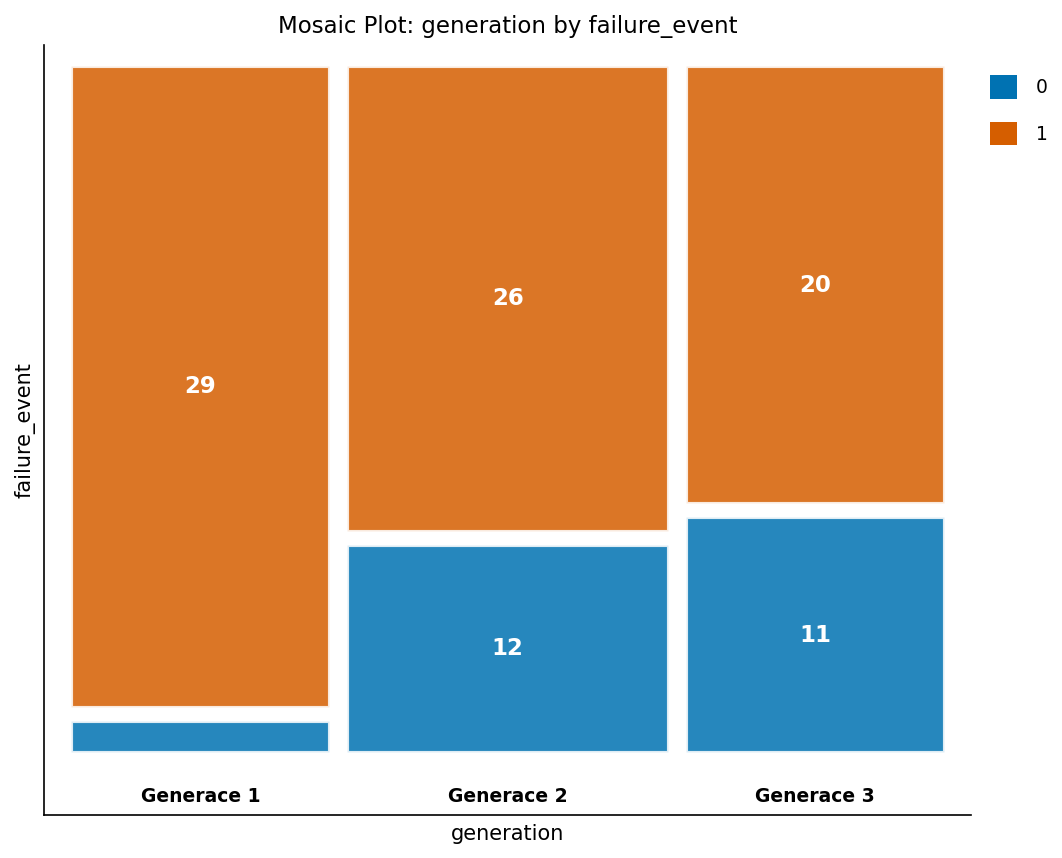

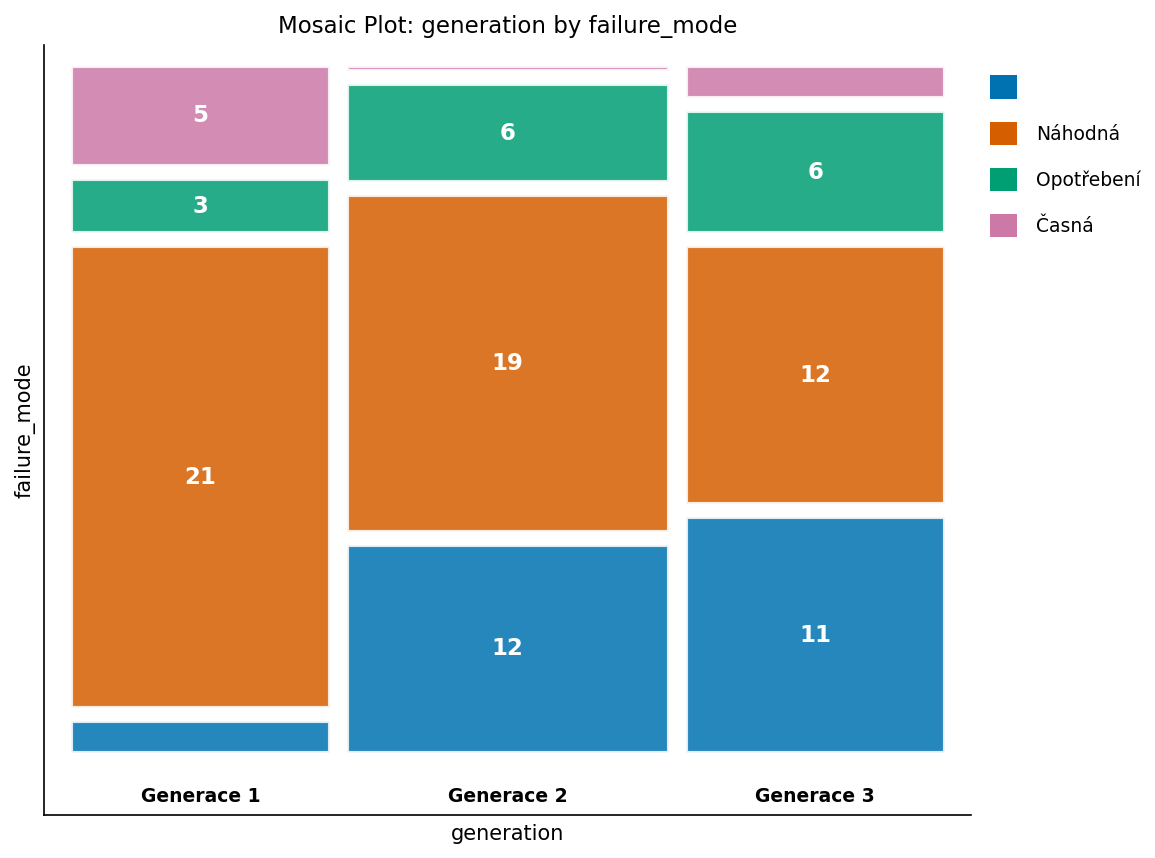

In [2]:
/* --------------------------------------------------------
   Základní počty zařízení a provozní hodiny podle generace
   -------------------------------------------------------- */
PROCEDURA ČETNOSTI data=work.equipment_life;
    ŠTÍTEK generation="Generace" failure_event="Porucha" failure_mode="Typ poruchy";
    TABLES generation * failure_event / nocol nopercent;
    TABLES generation * failure_mode / nocol norow;
SPUSTIT;

PROCEDURA PRŮMĚRY data=work.equipment_life n mean std;
    ŠTÍTEK generation="Generace" operating_hours="Provozní hodiny";
    TŘÍDA generation;
    PROMĚNNÁ operating_hours;
SPUSTIT;


---



NOTE: PROC SGPLOT data=work.equipment_life

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


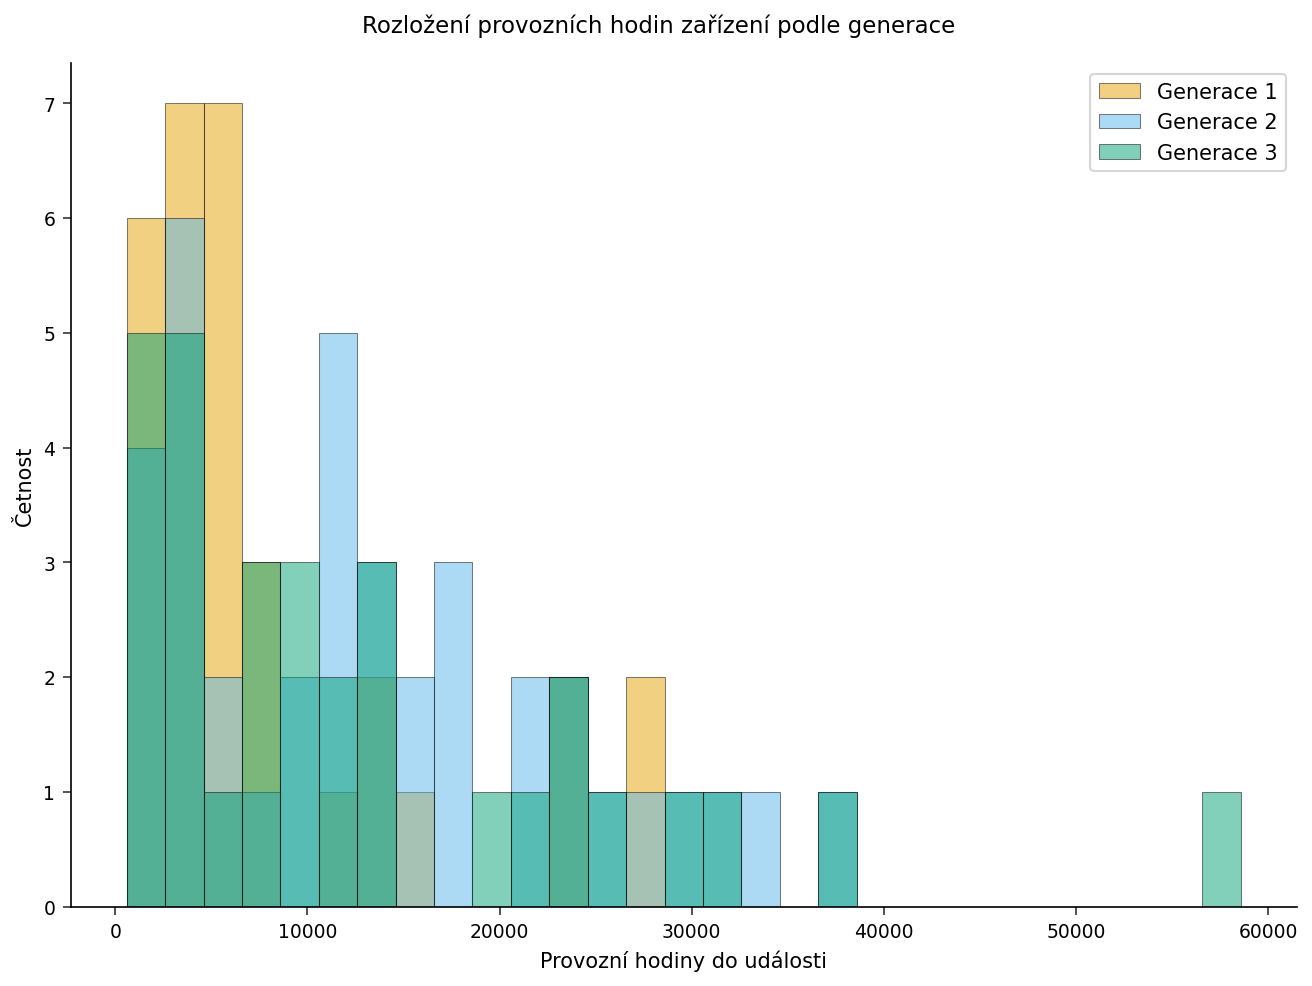

In [3]:
/* --------------------------------------------------------
   Rozložení provozních hodin podle generace
   -------------------------------------------------------- */
PROCEDURA SGPLOT data=work.equipment_life;
    ŠTÍTEK generation="Generace";
    HISTOGRAM operating_hours / GROUP=generation TRANSPARENCY=0.3 BINWIDTH=2000;
    XAXIS LABEL='Provozní hodiny do události';
    YAXIS LABEL='Četnost';
    NÁZEV 'Rozložení provozních hodin zařízení podle generace';
SPUSTIT;


---


    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

Stratum: Generace = Generace 1 

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.806


NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: OUTSURV dataset 'work.equip_cumhaz' written to: ./work/1430e2b6-113d-4d24-ace8-250b35d19c2f/equip_cumhaz.avro
NOTE: ODS plot written: lifetest_hazard.spec.json
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


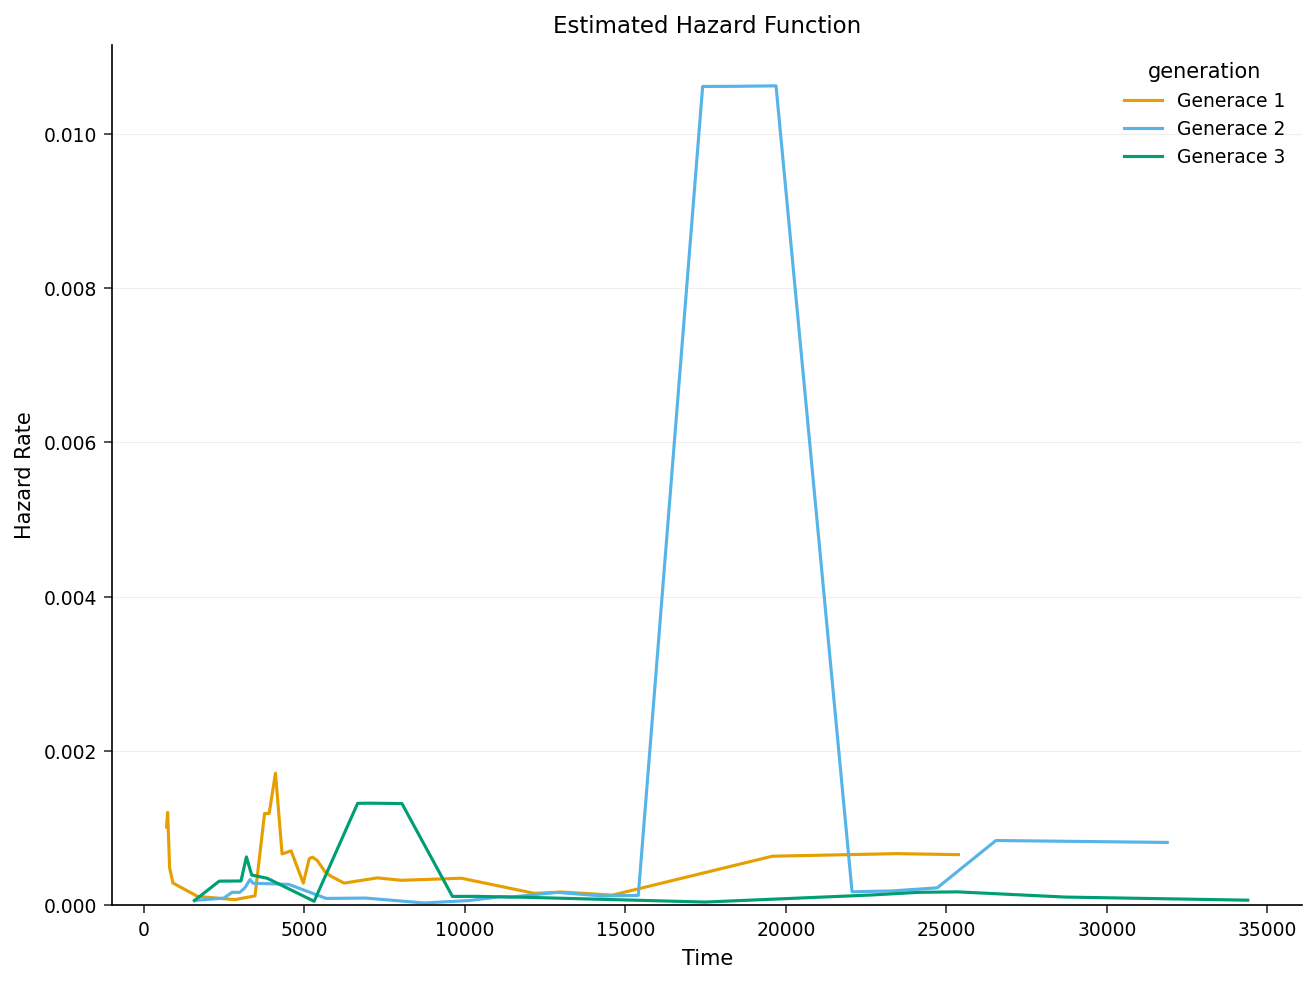

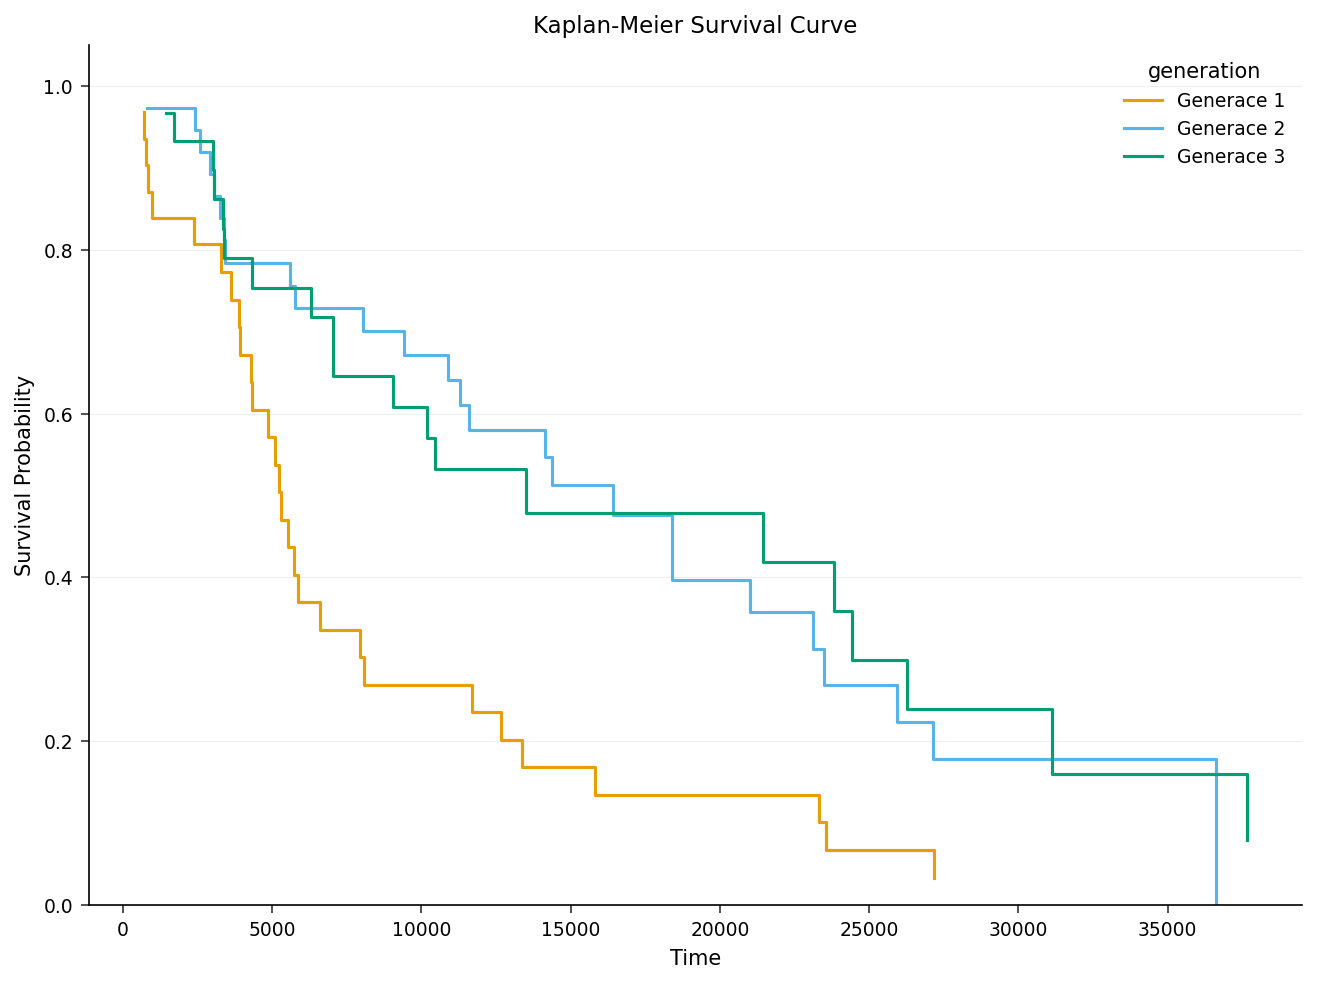

In [4]:
/* --------------------------------------------------------
   Kaplan-Meierův odhad přežití podle generace, s volbou
   Nelson-Aalenovy kumulativní míry rizika pro pohled na riziko.

   STRATA generation / TEST=(LOGRANK WILCOXON) provádí jak
   log-rank test (citlivý na rozdíly napříč celou provozní
   životností), tak test Gehan-Breslow-Wilcoxon (který
   nadhodnocuje časné poruchy) napříč třemi generacemi.

   PLOTS=(SURVIVAL HAZARD) vykreslí Kaplan-Meierovy křivky
   přežití a jádrově vyhlazenou funkci rizika.
   -------------------------------------------------------- */
PROCEDURA LIFETEST data=work.equipment_life
    METHOD=km
    nelson
    PLOTS=(SURVIVAL hazard)
    outsurv=work.equip_cumhaz;
    ŠTÍTEK generation="Generace";
    TIME operating_hours * failure_event(0);
    STRATA generation / TEST=(logrank WILCOXON);
SPUSTIT;


In [5]:
/* --------------------------------------------------------
   Pravděpodobnost přežití při milnících provozních hodin
   (5 000 / 10 000 / 20 000 / 30 000 hodin) pro každou generaci,
   čtená z Kaplan-Meierovy ODS tabulky.
   -------------------------------------------------------- */
ODS OUTPUT productlimitestimates=work.equip_km_detail;

PROCEDURA LIFETEST data=work.equipment_life METHOD=km;
    ŠTÍTEK generation="Generace";
    TIME operating_hours * failure_event(0);
    STRATA generation;
SPUSTIT;

ODS OUTPUT CLOSE;

/* Tabulka ProductLimitEstimates nese jeden řádek na jednotlivý
   čas uvnitř každé generace. Pro každý milník ponecháme první
   řádek, jehož čas je v daném milníku nebo za ním -- tedy odhad
   přežití platný v dané provozní hodině. */
PROCEDURA ŘADIT data=work.equip_km_detail;
    PODLE generation operating_hours;
SPUSTIT;

data work.equip_milestones;
    NASTAVIT work.equip_km_detail;
    PODLE generation;
    UCHOVAT hit5 hit10 hit20 hit30;
    KDYŽ first.generation PAK OPAKUJ;
        hit5 = 0; hit10 = 0; hit20 = 0; hit30 = 0;
    KONEC;
    DÉLKA milestone 8;
    milestone = .;
    KDYŽ      operating_hours >= 5000  AND hit5  = 0 PAK OPAKUJ; milestone = 5000;  hit5  = 1; KONEC;
    JINAK KDYŽ operating_hours >= 10000 AND hit10 = 0 PAK OPAKUJ; milestone = 10000; hit10 = 1; KONEC;
    JINAK KDYŽ operating_hours >= 20000 AND hit20 = 0 PAK OPAKUJ; milestone = 20000; hit20 = 1; KONEC;
    JINAK KDYŽ operating_hours >= 30000 AND hit30 = 0 PAK OPAKUJ; milestone = 30000; hit30 = 1; KONEC;
    KDYŽ milestone ne .;
    PONECHAT generation milestone operating_hours SURVIVAL sdf_stderr;
SPUSTIT;

PROCEDURA TISK data=work.equip_milestones noobs ŠTÍTEK;
    ŠTÍTEK generation     = "Generace"
          milestone       = "Milník (hodiny)"
          operating_hours = "Čas odhadu"
          SURVIVAL        = "Pravděpodobnost přežití"
          sdf_stderr      = "Směrodatná chyba";
    FORMÁT SURVIVAL sdf_stderr 6.4;
    NÁZEV 'Pravděpodobnost přežití při milnících provozních hodin podle generace';
SPUSTIT;


    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

Stratum: Generace = Generace 1 

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.806


NOTE: ODS OUTPUT: PRODUCTLIMITESTIMATES -> equip_km_detail
NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS OUTPUT: ProductLimitEstimates written to 'equip_km_detail'.
NOTE: PROC LIFETEST completed.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: PROC SORT data=work.equip_km_detail

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_km_detail (75 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.equip_milestones


NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_milestones (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=work.equip_milestones

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


---


### Interpretace

Kaplan-Meierovy křivky přežití rozdělují flotilu do dvou jasných úrovní.
Původní stroje **Generace 1** selhávají nejrychleji: jejich křivka klesne
pod 0,5 při **5 282 provozních hodinách** (medián provozní životnosti) a
do 10 000 hodin je v provozu jen asi **24 %**. Přepracované stroje
**Generace 2** a **Generace 3** vydrží mnohem déle -- mediány životnosti
**16 430**, respektive **13 512** hodin -- a jejich křivky přežití leží
těsně u sebe napříč celým pozorovaným rozsahem. Při milnících 5 000 /
10 000 / 20 000 hodin jsou odhadované pravděpodobnosti přežití:

| Generace | 5 000 h | 10 000 h | 20 000 h |
|------------|--------:|---------:|---------:|
| Generace 1 | 0,54 | 0,24 | 0,10 |
| Generace 2 | 0,76 | 0,64 | 0,36 |
| Generace 3 | 0,72 | 0,57 | 0,42 |

Oba testy shody vrstev zamítají nulovou hypotézu, že tři generace sdílejí
jedno rozdělení přežití: **log-rank** test dává chí-kvadrát **12,92**
(2 st. volnosti, *p* = **0,0016**) a test **Gehan-Breslow-Wilcoxon** dává
chí-kvadrát **11,88** (2 st. volnosti, *p* = **0,0026**). Oba testy se
shodují téměř přesně, takže rozdíl je tažen převážně délkou provozní
životnosti spíše než jen oblastí časných poruch (Wilcoxonův test
nadhodnocuje časné události).

Je důležité to číst jako **jednoskokové** zlepšení, nikoli jako
monotónní nárůst mezi generacemi. Generace 2 a Generace 3 jsou zde
statisticky nerozlišitelné -- jejich křivky se překrývají a medián
Generace 2 je nominálně vyšší z obou -- takže na tomto vzorku 100 strojů
neexistuje důkaz, že by Generace 3 zlepšila Generaci 2. Skutečným
signálem je velký, významný rozdíl mezi původním návrhem Generace 1 a
oběma pozdějšími návrhy.

Volba Nelson-Aalenovy kumulativní míry rizika řídí doprovodný graf
rizika. Při této velikosti vzorku je jádrově vyhlazená míra rizika
zašuměná -- vysoký hrot Generace 2 poblíž 18 000 hodin odráží jedinou
událost v malé zbývající rizikové skupině spíše než skutečný nárůst
opotřebení -- takže by se graf rizika měl chápat jako kvalitativní;
kvantitativní závěry nesou křivky přežití a formální testy.

**Doporučení.** Upřednostnit výměnu a přísnější kontrolu zbývajících
strojů Generace 1, jejichž spolehlivost je podstatně horší než u zbytku
flotily. Generaci 2 a Generaci 3 považovat za jednu, spolehlivější
kohortu pro plánování údržby, dokud větší vzorek nevyřeší případný rozdíl
mezi nimi.


---


In [6]:
/* --------------------------------------------------------
   Export dat o kumulativním riziku / křivce přežití a tabulky
   přežití pro milníky pro navazující dashboard spolehlivosti.
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.equip_cumhaz
    OUTFILE='equipment_cumulative_hazard.csv'
    DBMS=csv REPLACE;
SPUSTIT;

PROCEDURA EXPORTOVAT data=work.equip_milestones
    OUTFILE='equipment_milestone_survival.csv'
    DBMS=csv REPLACE;
SPUSTIT;



NOTE: PROC EXPORT data=work.equip_cumhaz outfile=equipment_cumulative_hazard.csv

NOTE: Exported 75 rows to equipment_cumulative_hazard.csv.
NOTE: PROC EXPORT data=work.equip_milestones outfile=equipment_milestone_survival.csv

NOTE: Exported 11 rows to equipment_milestone_survival.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Poháněno <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>